# YOLO11 객체인식 + TensorRT Quantization 실습

**Author**: Hyun-seo In (Hanyang Univ. BME/AE) — inhsroy@hanyang.ac.kr  
**Date**: 2026.05 | Jetson Orin Nano 8GB / JetPack 6.x

## 목차
1. 환경 확인
2. 라이브러리 설치 (Ultralytics)
3. CSI 카메라로 프레임 캡처
4. YOLO11 PyTorch 추론 (베이스라인)
5. ONNX 변환
6. TensorRT 엔진 빌드 (FP32 / FP16 / INT8 / INT8+Calib)
7. TensorRT 엔진으로 추론
8. 성능 비교 (FP32 / FP16 / INT8 / INT8 Calib)

## 1. 환경 확인

JetPack 설치 시 PyTorch / OpenCV / TensorRT 모두 자동 포함됨. 버전 확인부터.

In [ ]:
!python3 --version
!python3 -c "import torch; print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available())"
!python3 -c "import cv2; print('opencv:', cv2.__version__)"
!python3 -c "import tensorrt; print('tensorrt:', tensorrt.__version__)"

## 2. 라이브러리 설치 (Ultralytics)

> ⚠️ Jetson 주의사항
> - **OpenCV**: `pip install opencv-python` 금지 (apt 버전이 GStreamer/CUDA 지원)
> - **NumPy**: 2.x 호환성 깨짐 → 1.x 유지 필요
> - ultralytics 설치 시 numpy/opencv를 덮어쓰므로 설치 후 다운그레이드

In [ ]:
%pip install ultralytics

In [ ]:
# ultralytics가 설치한 pip opencv 제거 (apt 버전 사용)
%pip uninstall opencv-python -y

# numpy 1.x로 다운그레이드
%pip install "numpy<2.0"

# 'opencv-python not installed' 경고는 무시 가능 (apt cv2 사용 중)

In [ ]:
# 최종 확인
!python3 -c "import numpy; print('numpy:', numpy.__version__)"
!python3 -c "import cv2; print('opencv:', cv2.__version__)"
!python3 -c "from ultralytics import YOLO; print('ultralytics ok')"

## 3. CSI 카메라로 프레임 캡처

> ⚠️ Remote SSH 환경에서는 `cv2.imshow` 동작 안 함  
> GStreamer로 단일 프레임 캡처 → 파일 저장 → 추론 입력으로 사용

### 카메라 인식 확인

In [ ]:
!ls /dev/video*
# /dev/video0 출력되면 정상

### 단일 프레임 캡처 → test.jpg 저장

In [ ]:
!gst-launch-1.0 nvarguscamerasrc num-buffers=1 ! \
  'video/x-raw(memory:NVMM), width=1920, height=1080, format=NV12, framerate=30/1' ! \
  nvjpegenc ! filesink location=test.jpg
!ls -lh test.jpg

## 4. YOLO11 PyTorch 추론 (베이스라인)

> 💡 모델 크기: n < s < m < l < x  
> Jetson Orin Nano 8GB 기준 m까지 실시간 추론 가능. 본 실습은 nano 사용.

In [ ]:
from ultralytics import YOLO
import numpy as np

# 모델 자동 다운로드
model = YOLO("yolo11n.pt")
print("model loaded |", "classes:", len(model.names))

# 더미 추론 테스트
dummy = np.zeros((640, 640, 3), dtype=np.uint8)
results = model(dummy, verbose=False)
print("inference ok")

### 캡처한 이미지로 추론 → 결과 확인

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
img = cv2.imread("test.jpg")
results = model(img, verbose=False)
annotated = results[0].plot()

print(f"detections: {len(results[0].boxes)}")
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("PyTorch", fontsize=14)
plt.axis("off")
plt.show()

### Latency 측정 (더미 입력 100회)

In [ ]:
import torch, time
import numpy as np
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
dummy = np.zeros((640, 640, 3), dtype=np.uint8)

# warmup
for _ in range(10):
    model(dummy, verbose=False)

# 측정
times = []
for _ in range(100):
    start = time.time()
    model(dummy, verbose=False)
    torch.cuda.synchronize()
    times.append((time.time() - start) * 1000)

avg_ms = sum(times) / len(times)
print(f"[PyTorch] Latency: {avg_ms:.2f} ms | FPS: {1000/avg_ms:.1f}")

## 5. ONNX 변환

PyTorch `.pt` → ONNX `.onnx` (TensorRT가 읽을 수 있는 표준 포맷)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.export(format="onnx", imgsz=640, opset=17, simplify=True)

In [ ]:
!ls -lh yolo11n.onnx

## 6. TensorRT 엔진 빌드

> ⚠️ 처음 빌드는 **5~15분** 소요  
> 빌드된 엔진은 해당 Jetson 하드웨어 전용 (다른 기기 이식 불가)  
> ipynb에서 `!export ...` 는 동작 안 함 — `%%bash` 매직으로 실행해야 환경변수가 유지됨

In [ ]:
!mkdir -p engines logs

### FP32 엔진 빌드

In [ ]:
%%bash
export LD_LIBRARY_PATH=/usr/local/cuda-12.6/lib64:$LD_LIBRARY_PATH
/usr/src/tensorrt/bin/trtexec \
  --onnx=yolo11n.onnx \
  --saveEngine=engines/yolo11n_fp32.engine \
  2>&1 | tee logs/yolo_fp32.txt

### FP16 엔진 빌드

In [ ]:
%%bash
export LD_LIBRARY_PATH=/usr/local/cuda-12.6/lib64:$LD_LIBRARY_PATH
/usr/src/tensorrt/bin/trtexec \
  --onnx=yolo11n.onnx \
  --saveEngine=engines/yolo11n_fp16.engine \
  --fp16 \
  2>&1 | tee logs/yolo_fp16.txt

### INT8 엔진 빌드

> ⚠️ calibration dataset 없이 빌드 — TensorRT가 동적 범위를 자동 추정함  
> 정확도 보장이 필요한 배포 환경에서는 별도 calibrator 구현 필요

In [ ]:
%%bash
export LD_LIBRARY_PATH=/usr/local/cuda-12.6/lib64:$LD_LIBRARY_PATH
/usr/src/tensorrt/bin/trtexec \
  --onnx=yolo11n.onnx \
  --saveEngine=engines/yolo11n_int8.engine \
  --int8 \
  2>&1 | tee logs/yolo_int8.txt

### INT8 엔진 빌드 (with Calibration)

> 위 방식은 calibration 없이 빌드한 것으로 정확도가 크게 저하됨  
> ultralytics Python API를 사용하면 COCO128 이미지로 자동 calibration 수행  
> 빌드된 엔진에 메타데이터도 포함되어 `task=` 지정 불필요

> ⚠️ 처음 실행 시 COCO128 데이터셋 자동 다운로드 (~7MB)

In [1]:
from ultralytics import YOLO
import os, shutil

model = YOLO("yolo11n.pt")
model.export(
    format="engine",
    imgsz=640,
    int8=True,
    data="coco128.yaml",
    workspace=4,
)

# export()는 .pt와 같은 디렉토리에 .engine을 생성함 → engines/로 이동
src = "yolo11n.engine"
dst = "engines/yolo11n_int8_calib.engine"
if os.path.exists(src):
    shutil.move(src, dst)
    print(f"moved → {dst}")
else:
    print(f"already at {dst} or export path differs — check manually")
!ls -lh engines/yolo11n_int8_calib.engine

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.3.235 🚀 Python-3.10.12 torch-2.8.0 CUDA:0 (Orin, 7620MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'pip install --no-cache-dir "onnx>=1.12.0,<=1.19.1" "onnxruntime-gpu" ' returned non-zero exit status 1.
WARNING ⚠️ Retry 2/2 failed: Command 'pip install --no-cache-dir "onnx>=1.12.0,<=1.19.1" "onnxruntime-gpu" ' returned non-zero exit status 1.
WARNING ⚠️ requirements: ❌ Command 'pip install --no-cache-dir "onnx>=1.12.0,<=1.19.1" "onnxruntime-gpu" ' returned non-zero exit status 1.

ONNX: starting export with onnx 1.20.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export succ

In [2]:
!ls -lh engines/

total 41M
-rw-rw-r-- 1 hyunseo hyunseo 8.4M  5월  1 16:26 yolo11n_fp16.engine
-rw-rw-r-- 1 hyunseo hyunseo  13M  5월  1 16:16 yolo11n_fp32.engine
-rw-rw-r-- 1 hyunseo hyunseo 5.4M  5월  1 19:07 yolo11n_int8_calib.engine
-rw-rw-r-- 1 hyunseo hyunseo 4.4M  5월  1 16:35 yolo11n_int8.engine
-rw-rw-r-- 1 hyunseo hyunseo  11M  5월  1 16:06 yolo11n.onnx


## 7. TensorRT 엔진으로 추론

ultralytics가 `.engine` 파일 직접 로드 지원.

### FP32 엔진 추론

Loading engines/yolo11n_fp32.engine for TensorRT inference...
[05/01/2026-19:24:32] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[05/01/2026-19:24:32] [TRT] [I] Loaded engine size: 12 MiB
[05/01/2026-19:24:32] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[05/01/2026-19:24:32] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +19, now: CPU 1, GPU 60 (MiB)
WARNING ⚠️ Metadata not found for 'model=engines/yolo11n_fp32.engine'
FP32 detections: 47


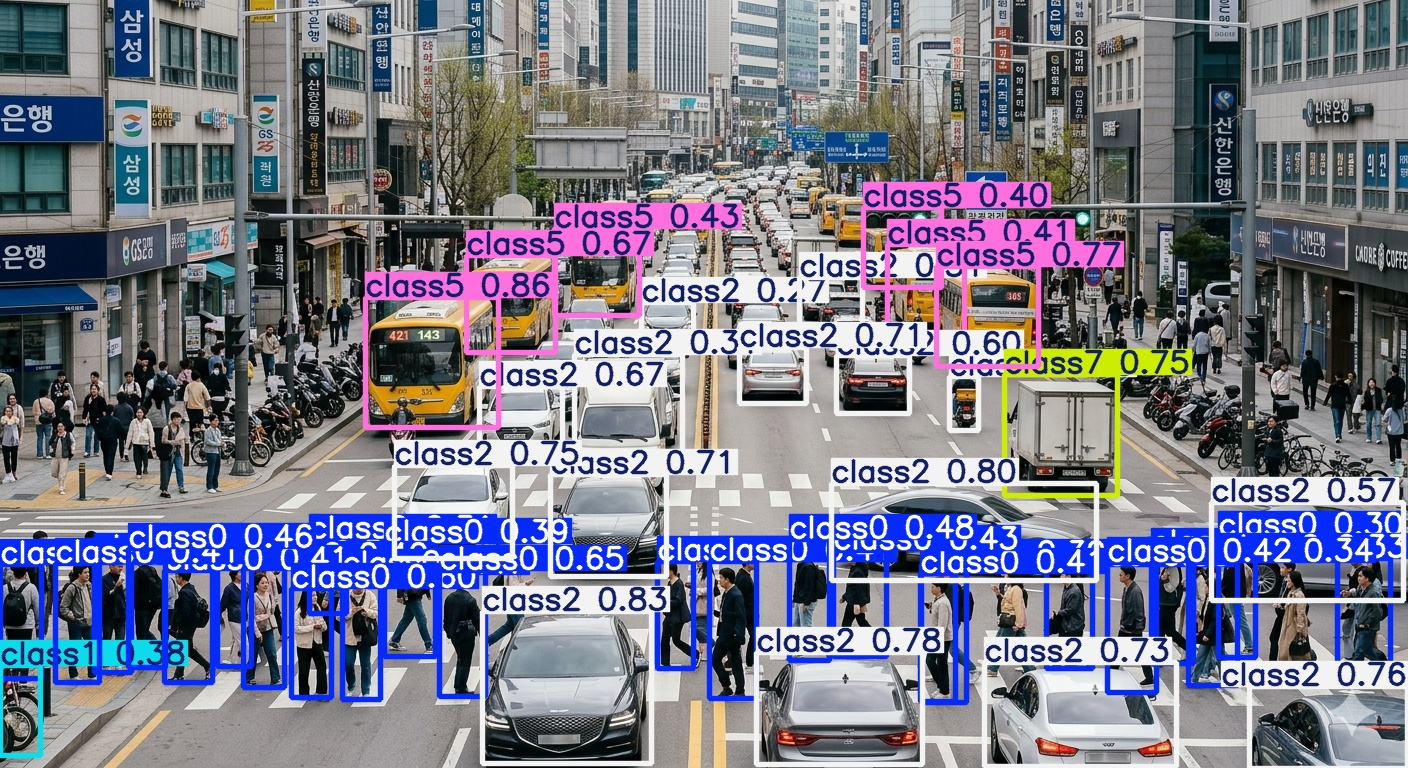

In [2]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from ultralytics import YOLO
import io

model_fp32 = YOLO("engines/yolo11n_fp32.engine", task="detect")
img = cv2.imread("test.jpg")
results = model_fp32(img, verbose=False)
annotated = results[0].plot()  # BGR numpy array

print(f"FP32 detections: {len(results[0].boxes)}")

# 메모리에서 바로 인코딩 → 표시
_, buf = cv2.imencode(".jpg", annotated)
display(IPImage(data=buf.tobytes()))

### FP16 엔진 추론

Loading engines/yolo11n_fp16.engine for TensorRT inference...
[05/01/2026-19:25:13] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[05/01/2026-19:25:13] [TRT] [I] Loaded engine size: 8 MiB
[05/01/2026-19:25:13] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[05/01/2026-19:25:13] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +10, now: CPU 3, GPU 106 (MiB)
WARNING ⚠️ Metadata not found for 'model=engines/yolo11n_fp16.engine'
FP16 detections: 46


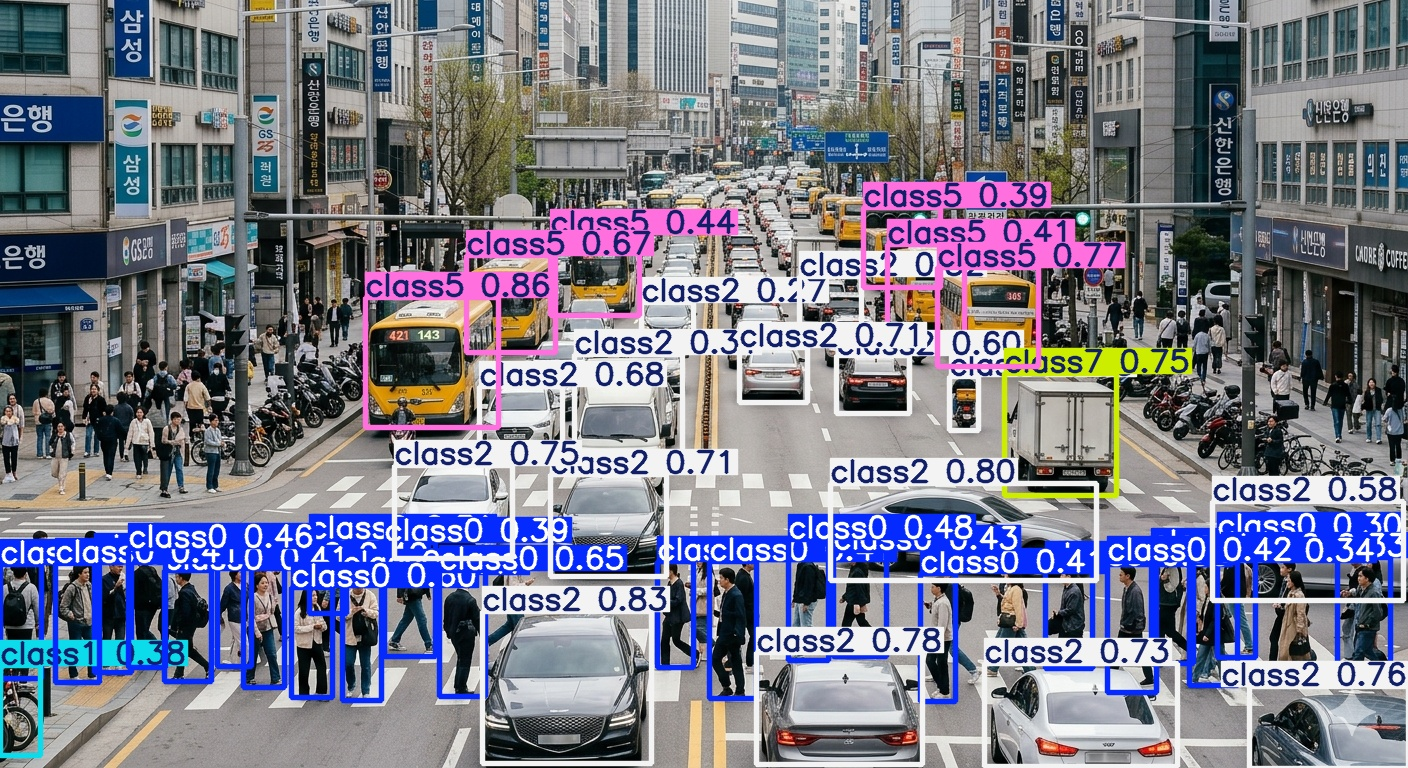

In [5]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from ultralytics import YOLO
import io

model_fp16 = YOLO("engines/yolo11n_fp16.engine", task="detect")
img = cv2.imread("test.jpg")
results = model_fp16(img, verbose=False)
annotated = results[0].plot()  # BGR numpy array

print(f"FP16 detections: {len(results[0].boxes)}")

# 메모리에서 바로 인코딩 → 표시
_, buf = cv2.imencode(".jpg", annotated)
display(IPImage(data=buf.tobytes()))

### INT8 엔진 추론 (without Calibration)

Loading engines/yolo11n_int8.engine for TensorRT inference...
[05/01/2026-19:25:41] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[05/01/2026-19:25:41] [TRT] [I] Loaded engine size: 4 MiB
[05/01/2026-19:25:41] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[05/01/2026-19:25:41] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +12, now: CPU 4, GPU 120 (MiB)
WARNING ⚠️ Metadata not found for 'model=engines/yolo11n_int8.engine'
INT8 detections: 0


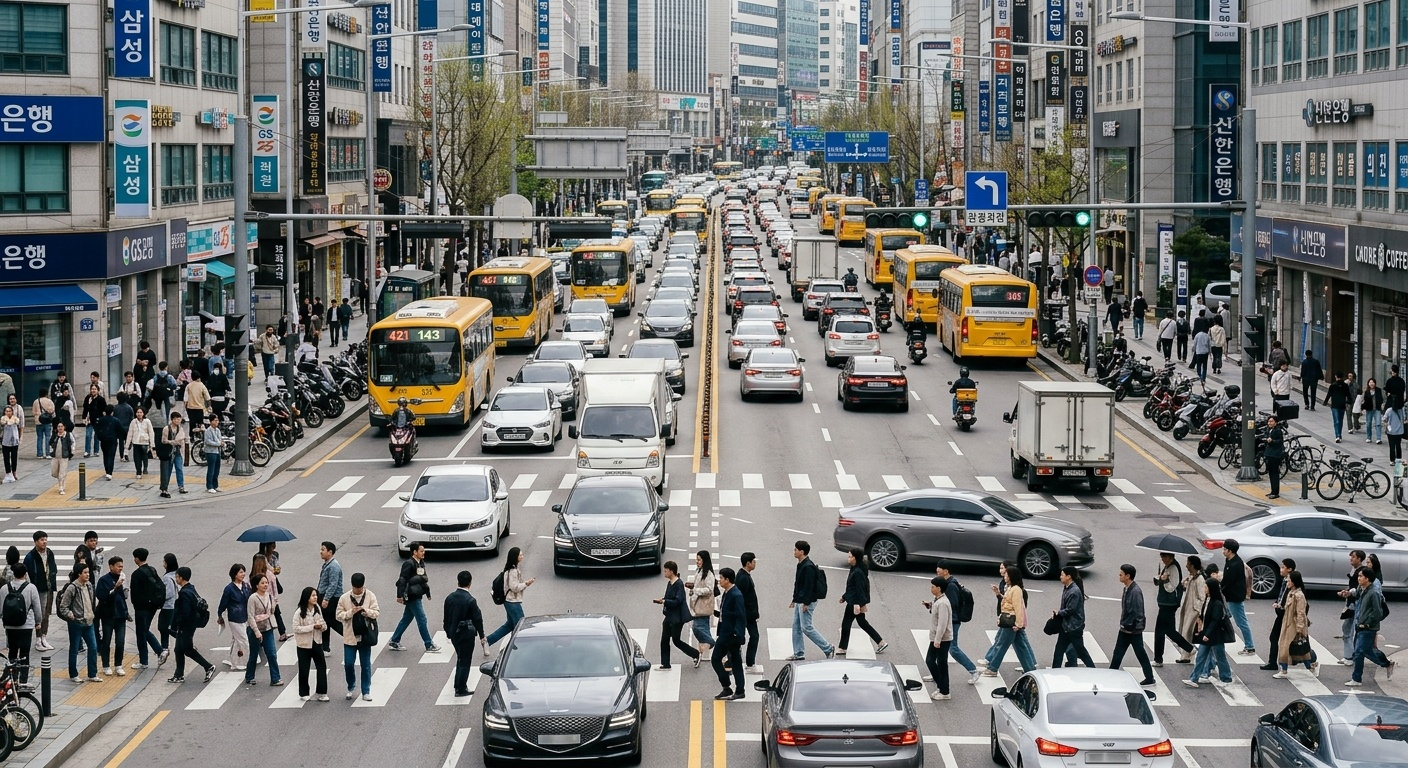

In [6]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from ultralytics import YOLO
import io

model_int8 = YOLO("engines/yolo11n_int8.engine", task="detect")
img = cv2.imread("test.jpg")
results = model_int8(img, verbose=False)
annotated = results[0].plot()  # BGR numpy array

print(f"INT8 detections: {len(results[0].boxes)}")

# 메모리에서 바로 인코딩 → 표시
_, buf = cv2.imencode(".jpg", annotated)
display(IPImage(data=buf.tobytes()))

### INT8 엔진 추론 (with Calibration)

Loading engines/yolo11n_int8_calib.engine for TensorRT inference...
[05/01/2026-19:26:06] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[05/01/2026-19:26:06] [TRT] [I] Loaded engine size: 5 MiB
[05/01/2026-19:26:06] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +12, now: CPU 3, GPU 89 (MiB)
INT8 (calib) detections: 50


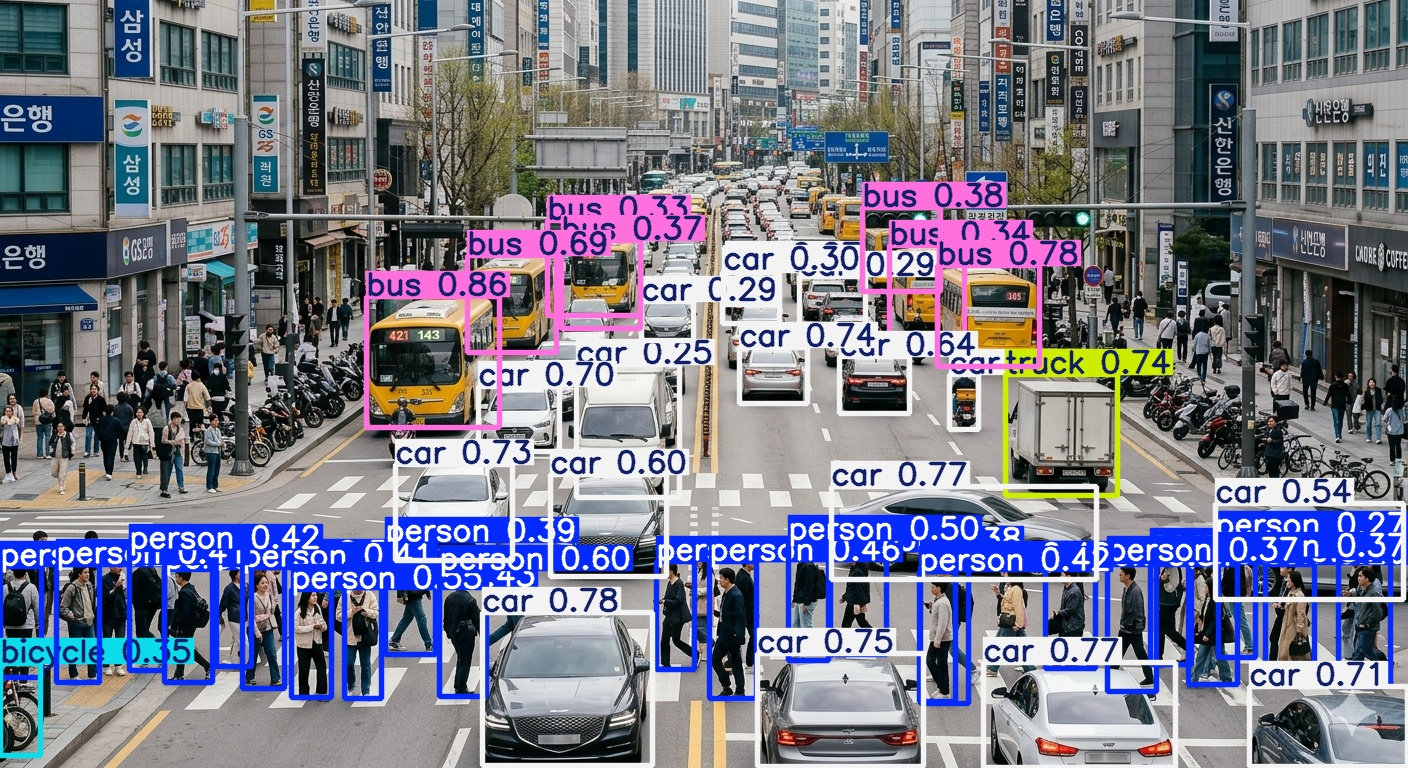

In [7]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from ultralytics import YOLO
import io

model_int8_calib = YOLO("engines/yolo11n_int8_calib.engine", task="detect")
img = cv2.imread("test.jpg")
results = model_int8_calib(img, verbose=False)
annotated = results[0].plot()  # BGR numpy array

print(f"INT8 (calib) detections: {len(results[0].boxes)}")

# 메모리에서 바로 인코딩 → 표시
_, buf = cv2.imencode(".jpg", annotated)
display(IPImage(data=buf.tobytes()))

## 8. 성능 비교 (FP32 / FP16 / INT8 / INT8 Calib)

In [9]:
import cv2, time, logging, warnings, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("ultralytics").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

from ultralytics import YOLO

models = {
    "PyTorch":  YOLO("yolo11n.pt"),
    "TRT FP32": YOLO("engines/yolo11n_fp32.engine", task="detect"),
    "TRT FP16": YOLO("engines/yolo11n_fp16.engine", task="detect"),
    "TRT INT8": YOLO("engines/yolo11n_int8.engine", task="detect"),
}

img = cv2.imread("test.jpg")

print(f"{'Backend':<12} {'Latency (ms)':<15} {'FPS':<10}")
print("-" * 40)
for name, model in models.items():
    for _ in range(5):
        model(img, verbose=False)
    times = []
    for _ in range(50):
        start = time.time()
        model(img, verbose=False)
        times.append((time.time() - start) * 1000)
    avg_ms = sum(times) / len(times)
    print(f"{name:<12} {avg_ms:<15.2f} {1000/avg_ms:<10.1f}")

Backend      Latency (ms)    FPS       
----------------------------------------
PyTorch      83.74           11.9      
[05/01/2026-19:28:22] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[05/01/2026-19:28:22] [TRT] [I] Loaded engine size: 12 MiB
[05/01/2026-19:28:22] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[05/01/2026-19:28:22] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +20, now: CPU 6, GPU 163 (MiB)
TRT FP32     99.25           10.1      
[05/01/2026-19:28:28] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLog

### 정확도 차이 시각 비교

FP32 / FP16 / INT8 / INT8 Calib 결과를 나란히 표시

[05/01/2026-19:29:30] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[05/01/2026-19:29:30] [TRT] [I] Loaded engine size: 12 MiB
[05/01/2026-19:29:30] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[05/01/2026-19:29:30] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +1, GPU +19, now: CPU 9, GPU 222 (MiB)
[05/01/2026-19:29:30] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[05/01/2026-19:29:30] [TRT] [I] Loaded engine size: 8 MiB
[05/01/2026-19:29:30] [TRT] [W] Using an engine plan file across

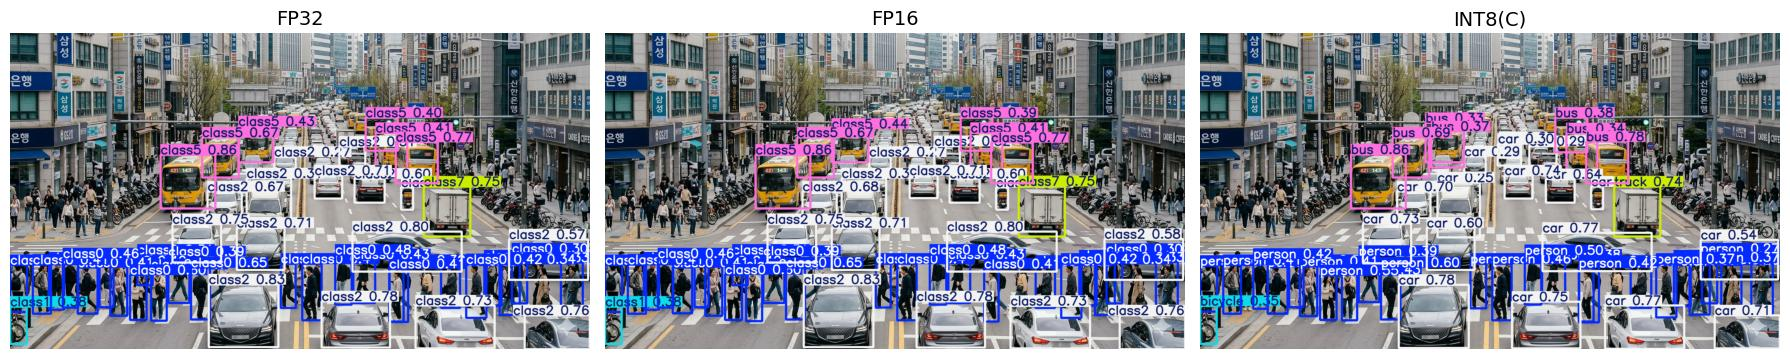

In [11]:
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from ultralytics import YOLO
import io

img = cv2.imread("test.jpg")
fp32 = YOLO("engines/yolo11n_fp32.engine", task="detect")(img, verbose=False)[0].plot()
fp16 = YOLO("engines/yolo11n_fp16.engine", task="detect")(img, verbose=False)[0].plot()
int8 = YOLO("engines/yolo11n_int8_calib.engine", task="detect")(img, verbose=False)[0].plot()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, result_img, label in zip(axes, [fp32, fp16, int8], ["FP32", "FP16", "INT8(C)"]):
    ax.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    ax.set_title(label, fontsize=14)
    ax.axis("off")
plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format="jpg", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close()

### trtexec 실측 성능 (Jetson Orin Nano 8GB 기준)

| Backend | Engine 크기 | GPU Latency (median) | Throughput | FP32 대비 속도 |
|---------|------------|---------------------|------------|---------------|
| TRT FP32 | 12.2 MiB | 7.80 ms | 123.8 qps | 1.0x |
| TRT FP16 | 8.4 MiB | 4.20 ms | 233.1 qps | 1.86x |
| TRT INT8 | 4.3 MiB | 3.31 ms | 298.3 qps | 2.36x |

> ⚠️ trtexec INT8은 calibration 없이 빌드한 수치 — 속도는 빠르지만 정확도 보장 안 됨  
> Calibration 적용한 INT8(`yolo11n_int8_calib.engine`)은 정확도가 거의 FP32 수준으로 회복됨